## Pitch Visualization

In [27]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

# Datenset laden

In [28]:
data = pd.read_csv('../data/DATASET CSV 11-02-2026.csv', sep=';')
data['br-pos'] = pd.to_numeric(data['br-pos'], errors='coerce')
data['annahme'] = pd.to_numeric(data['annahme'], errors='coerce')

# Überblick über die Daten schaffen

In [29]:
data.head()
data.shape
print(data.columns)
data.info()
data.isna().sum()
unique_titel = data['titel_kurz_d'].unique()
len(unique_titel)
unique_titel[:20]

Index(['anr', 'datum', 'titel_kurz_d', 'titel_kurz_f', 'titel_kurz_e',
       'titel_off_d', 'titel_off_f', 'stichwort', 'swissvoteslink', 'anzahl',
       ...
       'bkresults-fr', 'bfsdash-de', 'bfsdash-fr', 'bfsdash-en', 'bfsmap-de',
       'bfsmap-fr', 'bfsmap-en', 'nach_cockpit_d', 'nach_cockpit_f',
       'nach_cockpit_e'],
      dtype='object', length=874)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Columns: 874 entries, anr to nach_cockpit_e
dtypes: float64(482), int64(10), object(382)
memory usage: 4.7+ MB


array(['Bundesverfassung der schweizerischen Eidgenossenschaft',
       'Mass und Gewicht',
       'Gleichstellung der Juden und Naturalisierten mit Bezug auf Niederlassung',
       'Stimmrecht der Niedergelassenen in Gemeindeangelegenheiten',
       'Besteuerung und zivilrechtliche Verhältnisse der Niedergelassenen',
       'Stimmrecht der Niedergelassenen in kantonalen Angelegenheiten',
       'Glaubens- und Kultusfreiheit',
       'Ausschliessung einzelner Strafarten',
       'Schutz des geistigen Eigentums',
       'Verbot der Lotterie und Hasardspiele',
       'Bundesverfassung (Totalrevision)',
       'Gesetz betreffend Feststellung und Beurkundung des Zivilstandes und die Ehe',
       'Gesetz über die politische Stimmberechtigung der Schweizerbürger',
       'Banknotengesetz',
       'Gesetz betreffend die Militärpflichtersatzsteuer', 'Fabrikgesetz',
       'Gesetz betreffend den Militärpflichtersatz',
       'Politische Rechte der Niedergelassenen und Aufenthalter',
       'Sub

# Wrangling und Datacleaning

In [30]:
data['datum'] = pd.to_datetime(data['datum'], format='%d.%m.%Y')

data.replace([9999,999], np.nan, inplace=True)

# Kongruenz-Spalte erstellen (Regierungstreue)
#br-pos: 1 = Ja, 2 = Nein, 8 = Vorzug Gegenentwurf | Volksmehr: 1 = Angenommen, 0 = Abgelehnt, 8 = Vorzug Gegenentwurf

data['regierungstreue'] = np.where(
     ((data['br-pos'] == 1) & (data['volk'] == 1)) |
     ((data['br-pos'] == 2) & (data['volk'] == 0)) |
     ((data['br-pos'] == 8) & (data['volk'] == 8)) |
    ((data['br-pos'] == 9) & (data['volk'] == 9)),
     1,
     0
 )


data['regierungstreue'] = np.where(
    data['br-pos'].isin([1, 2]),
    np.where(
        ((data['br-pos'] == 1) & (data["volkja-proz"] > 50.0)) |
        ((data['br-pos'] == 2) & (data["volkja-proz"] < 50.0)),
        1,
        0
    ),
    np.nan
)
for col in ['d1e1', 'd1e2', 'd1e3', 'd2e1', 'd2e2', 'd2e3', 'd3e1', 'd3e2', 'd3e3']:
    print(f"\n{col}")
    print(data[col].value_counts(dropna=False).head(20))
    
hauptgruppen_map = {
    1: 'Staatsordnung & Politische Rechte',
    2: 'EU & Aussenpolitik',
    3: 'Armee & Sicherheit',
    4: 'Wirtschaft & Arbeit',
    5: 'Landwirtschaft',
    6: 'Finanzen & Steuern',
    7: 'Energie',
    8: 'Verkehr & Infrastruktur',
    9: 'Klima & Umwelt',
    10: 'Soziale Sicherheit & Gesellschaft',
    11: 'Bildung & Forschung',
    12: 'Kultur, Religion & Medien'
}

data['Hauptgruppe'] = data['d1e1'].map(hauptgruppen_map)


def assign_hauptgruppe(row):
    d1 = row['d1e1']
    d2 = row['d1e2']
    d3 = row['d1e3']

    if d1 == 10:
        if d2 == 1:
            return 'Gesundheit'
        elif d2 == 2:
            return 'Soziale Sicherheit'
        elif d2 == 3:
            return 'Migration & Gesellschaft'
        else:
            return 'Soziale Sicherheit & Gesellschaft'

    elif d1 == 11:
        return 'Bildung & Forschung'
    elif d1 == 12:
        return 'Kultur, Religion & Medien'
    elif d1 == 2:
        return 'EU & Aussenpolitik'
    elif d1 == 3:
        return 'Armee & Sicherheit'
    elif d1 in [7, 9]:
        return 'Klima & Umwelt'
    elif d1 == 6:
        return 'Finanzen & Steuern'
    elif d1 == 8:
        return 'Verkehr & Infrastruktur'
    elif d1 == 4:
        return 'Wirtschaft & Arbeit'
    elif d1 == 5:
        return 'Landwirtschaft'
    elif d1 == 1:
        return 'Staatsordnung & Politische Rechte'
    else:
        return 'Andere'
    
data['Hauptgruppe'] = data.apply(assign_hauptgruppe, axis=1)

data['Hauptgruppe'].value_counts(dropna=False)
data[['titel_kurz_d', 'd1e1', 'd1e2', 'd1e3', 'Hauptgruppe']].sample(20, random_state=42)
data[data['Hauptgruppe'].isna()][['titel_kurz_d', 'd1e1', 'd1e2', 'd1e3']].head(20)

# Labels für die Spalte Rechtsform vergeben
rechtsform_map = {
    1: 'Obligatorisches Referendum',
    2: 'Fakultatives Referendum',
    3: 'Volksinitiative',
    4: 'Direkter Gegenentwurf',
    5: 'Stichfrage'
}

data['rechtsform_name'] = data['rechtsform'].map(rechtsform_map)

# Abstimmungen in den Kantonen: Spalten ordnen
kanton_cols = [col for col in data.columns if col.endswith('-japroz')]
print(kanton_cols)
print(len(kanton_cols))

kanton_df = data.melt(
    id_vars=['anr', 'titel_kurz_d', 'regierungstreue', 'br-pos', 'annahme'],
    value_vars=kanton_cols,
    var_name='Kanton',
    value_name='Ja_Anteil'
)

kanton_df['Kanton'] = kanton_df['Kanton'].str.replace('-japroz', '', regex=False).str.upper()

# Jahre umwandeln
data['jahr'] = data['datum'].dt.year

# Vorbereitung für Visualisierungen
plot_data = data[
    data['br-pos'].isin([1, 2]) &
    data['annahme'].isin([0, 1])
].copy()

### CHARLOTTE: WÜRDE für die meisten Analysen LEGISJAHR NEHMEN --> DEKADE LÖSCHEN
plot_data['jahr'] = plot_data['datum'].dt.year
plot_data['dekade'] = (plot_data['jahr'] // 10) * 10

### CHARLOTTE: WÜRDE ICH NICHT SO MACHEN. GROSSER KONZEPTIONELLER UNTERSCHIED ZWISCHEN DEN BEIDEN.
##plot_data['rechtsform_group'] = plot_data['rechtsform_name'].replace({
#   'Obligatorisches Referendum': 'Referendum',
#    'Fakultatives Referendum': 'Referendum'
#})

# Kantonale Annahme-Spalten finden
kanton_annahme_cols = [col for col in data.columns if col.endswith('-annahme')]

# In Long-Format bringen
kanton_vote_df = data.melt(
    id_vars=['anr', 'titel_kurz_d', 'br-pos'],
    value_vars=kanton_annahme_cols,
    var_name='Kanton',
    value_name='kanton_annahme'
)

# Kantonskürzel bereinigen
kanton_vote_df['Kanton'] = kanton_vote_df['Kanton'].str.replace('-annahme', '', regex=False).str.upper()

# Nur klare Fälle behalten
kanton_vote_df = kanton_vote_df[
    kanton_vote_df['br-pos'].isin([1, 2]) &
    kanton_vote_df['kanton_annahme'].isin([0, 1])
].copy()

# Kantonale Regierungstreue berechnen
kanton_vote_df['kanton_regierungstreue'] = np.where(
    ((kanton_vote_df['br-pos'] == 1) & (kanton_vote_df['kanton_annahme'] == 1)) |
    ((kanton_vote_df['br-pos'] == 2) & (kanton_vote_df['kanton_annahme'] == 0)),
    1,
    0
)

# Sprachregionen zuordnen
sprachregion_map = {
    'ZH': 'Deutschschweiz', 'BE': 'Deutschschweiz', 'LU': 'Deutschschweiz',
    'UR': 'Deutschschweiz', 'SZ': 'Deutschschweiz', 'OW': 'Deutschschweiz',
    'NW': 'Deutschschweiz', 'GL': 'Deutschschweiz', 'ZG': 'Deutschschweiz',
    'FR': 'Romandie', 'SO': 'Deutschschweiz', 'BS': 'Deutschschweiz',
    'BL': 'Deutschschweiz', 'SH': 'Deutschschweiz', 'AR': 'Deutschschweiz',
    'AI': 'Deutschschweiz', 'SG': 'Deutschschweiz', 'GR': 'Deutschschweiz',
    'AG': 'Deutschschweiz', 'TG': 'Deutschschweiz', 'TI': 'Tessin',
    'VD': 'Romandie', 'VS': 'Romandie', 'NE': 'Romandie',
    'GE': 'Romandie', 'JU': 'Romandie'
}

# Pro Kanton mitteln
kanton_summary = (
    kanton_vote_df.groupby('Kanton', as_index=False)['kanton_regierungstreue']
    .mean()
)

kanton_summary['Sprachregion'] = kanton_summary['Kanton'].map(sprachregion_map)

# Nach Regierungstreue sortieren
kanton_summary = kanton_summary.sort_values('kanton_regierungstreue')

# Kantons-Spalten
kanton_cols = [col for col in data.columns if col.endswith('-japroz')]

# Long-Format: jede Abstimmung x jeder Kanton
heatmap_df = data.melt(
    id_vars=['anr', 'titel_kurz_d', 'Hauptgruppe'],
    value_vars=kanton_cols,
    var_name='Kanton',
    value_name='Ja_Anteil'
)

# Kantonsnamen bereinigen
heatmap_df['Kanton'] = heatmap_df['Kanton'].str.replace('-japroz', '', regex=False).str.upper()

# Ja-Anteil numerisch
heatmap_df['Ja_Anteil'] = pd.to_numeric(heatmap_df['Ja_Anteil'], errors='coerce')

# Fehlende Werte entfernen
heatmap_df = heatmap_df.dropna(subset=['Ja_Anteil', 'Hauptgruppe'])

# Durchschnittlicher Ja-Anteil pro Hauptgruppe und Kanton
heatmap_data = (
    heatmap_df.groupby(['Hauptgruppe', 'Kanton'])['Ja_Anteil']
    .mean()
    .reset_index()
    .pivot(index='Hauptgruppe', columns='Kanton', values='Ja_Anteil')
)


d1e1
d1e1
10    142
1     107
4      86
6      71
8      58
3      53
9      49
5      38
2      34
11     25
7      24
12     21
Name: count, dtype: int64

d1e2
d1e2
10.2    61
4.1     50
10.3    42
6.1     42
3.2     40
10.1    39
1.6     35
1.3     32
8.2     29
1.4     21
9.3     19
4.2     19
9.2     18
4.3     17
5.3     16
6.2     14
9.1     12
2.2     12
3.1     12
5.1     11
Name: count, dtype: int64

d1e3
d1e3
.        194
10.21     25
10.31     21
10.14     19
10.24     19
6.13      17
4.31      15
1.65      14
4.13      14
3.23      14
6.14      13
1.31      13
10.11     11
1.32      11
9.21      10
4.14      10
2.22      10
8.21       9
4.11       9
9.22       8
Name: count, dtype: int64

d2e1
d2e1
.      213
1      128
10      85
6       84
4       57
9       52
3       24
5       14
2       14
11      10
12       9
7        9
8        6
NaN      3
Name: count, dtype: int64

d2e2
d2e2
.       222
6.1      63
10.3     52
1.6      48
9.3      44
1.5      33
10.2     23
1.2

# Visualisierungen

## BR vs Parlament

### Data Wrangling

In [31]:
# Positionen Bundesrat
data['br-pos_label'] = data['br-pos'].map({
    1: 'Befürwortend',
    2: 'Ablehnend',
    3: 'Keine Empfehlung',
    8: "Stichfragen: Vorzug Gegenentwurf",
    9: "Stichfragen: Vorzug Volksinitiative"
})
data['br-pos_label'] = data['br-pos_label'].fillna("Missing")
data['br-pos_label'].value_counts()


br-pos_label
Befürwortend                        333
Ablehnend                           235
Missing                             129
Keine Empfehlung                      7
Stichfragen: Vorzug Gegenentwurf      4
Name: count, dtype: int64

In [32]:
# Positionen Parlament
data['bv-pos_label'] = data['bv-pos'].map({
    1: 'Befürwortend',
    2: 'Ablehnend',
    3: 'Keine Abstimmungsempfehlung',
    8: "Stichfragen: Vorzug Gegenentwurf",
    9: "Stichfragen: Vorzug Volksinitiative"
})
data['bv-pos_label'] = data['bv-pos_label'].fillna("Missing")
data['bv-pos_label'].value_counts()

bv-pos_label
Befürwortend                        466
Ablehnend                           231
Keine Abstimmungsempfehlung           7
Stichfragen: Vorzug Gegenentwurf      4
Name: count, dtype: int64

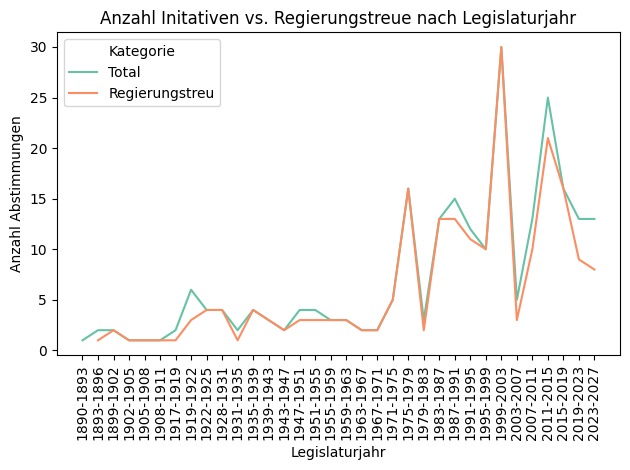

In [33]:
# df Volksinitativen über Zeit
i_df = data[(data["rechtsform_name"] == "Volksinitiative") & ((data["br-pos"] != "Missing") | (data["br-pos"] != 3))
].copy()

total = i_df.groupby("legisjahr").size().reset_index(name="anzahl")
total["Kategorie"] = "Total"

i_regtreu = i_df[i_df["regierungstreue"] == 1].groupby("legisjahr").size().reset_index(name="anzahl")
i_regtreu["Kategorie"] = "Regierungstreu"

combined = pd.concat([total, i_regtreu])

sns.lineplot(data=combined, x="legisjahr", y="anzahl", hue="Kategorie", palette="Set2")
plt.xlabel('Legislaturjahr')
plt.xticks(rotation=90)
plt.ylabel('Anzahl Abstimmungen')
plt.title('Anzahl Initativen vs. Regierungstreue nach Legislaturjahr')
plt.tight_layout()
plt.show()

In [34]:
i_disagreement = i_df[
    (i_df["regierungstreue"] != 1)]
print(i_disagreement[["titel_kurz_d", "Hauptgruppe"]])
i_disagreement["Hauptgruppe"].value_counts()

                                          titel_kurz_d  \
39                    Initiative für ein Schächtverbot   
41   Initiative «zur Gewährleistung des Rechts auf ...   
67                  Initiative «für ein Absinthverbot»   
76   Initiative «für die Proporzwahl des Nationalra...   
81           Initiative für ein Verbot der Spielbanken   
85         Initiative für ein Staatsvertragsreferendum   
91   Initiative «betreffend die Wählbarkeit der Bun...   
123  Initiative für eine Totalrevision der Bundesve...   
150  Initiative «für die Rückkehr zur direkten Demo...   
177            Mieter- und Konsumentenschutzinitiative   
321                       Preisüberwachungs-Initiative   
362  Initiative «zum Schutz der Moore - Rothenthurm...   
378  Initiative «Stopp dem Atomkraftwerkbau (Morato...   
420                                   Alpen-Initiative   
522  Initiative für eine lebenslange Verwahrung für...   
536  Initiative «für Lebensmittel aus gentechnikfre...   
551  Initiativ

Hauptgruppe
Staatsordnung & Politische Rechte    9
Wirtschaft & Arbeit                  7
Soziale Sicherheit & Gesellschaft    6
Klima & Umwelt                       3
Landwirtschaft                       2
Kultur, Religion & Medien            2
Armee & Sicherheit                   1
Verkehr & Infrastruktur              1
EU & Aussenpolitik                   1
Name: count, dtype: int64

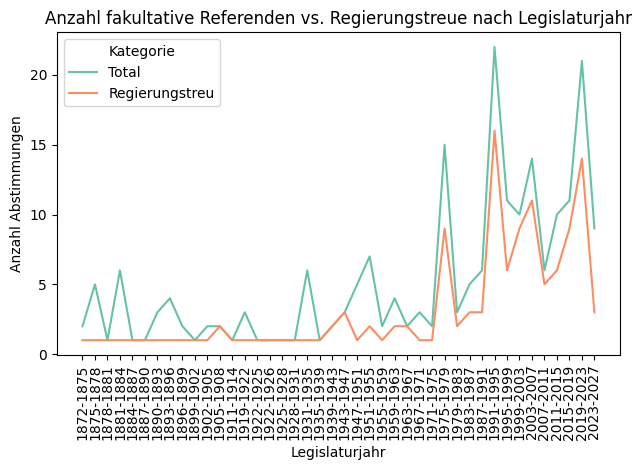

In [35]:
# df fakultatives Referendum über Zeit
fr_df = data[
    (data["rechtsform_name"] == "Fakultatives Referendum") &
    ((data["br-pos"] != "Missing") | (data["br-pos"] != 3))
].copy()

total = fr_df.groupby("legisjahr").size().reset_index(name="anzahl")
total["Kategorie"] = "Total"

regtreu = fr_df[fr_df["regierungstreue"] == 1].groupby("legisjahr").size().reset_index(name="anzahl")
regtreu["Kategorie"] = "Regierungstreu"

combined = pd.concat([total, regtreu])

sns.lineplot(data=combined, x="legisjahr", y="anzahl", hue="Kategorie", palette="Set2")
plt.xlabel('Legislaturjahr')
plt.xticks(rotation=90)
plt.ylabel('Anzahl Abstimmungen')
plt.title('Anzahl fakultative Referenden vs. Regierungstreue nach Legislaturjahr')
plt.tight_layout()
plt.show()

In [36]:
fr_disagreement = fr_df[
    (fr_df["regierungstreue"] != 1)]
print(fr_disagreement[["titel_kurz_d", "Hauptgruppe"]])
fr_disagreement["Hauptgruppe"].value_counts()

                                          titel_kurz_d  \
13   Gesetz über die politische Stimmberechtigung d...   
14                                     Banknotengesetz   
15    Gesetz betreffend die Militärpflichtersatzsteuer   
17          Gesetz betreffend den Militärpflichtersatz   
18   Politische Rechte der Niedergelassenen und Auf...   
..                                                 ...   
691                          Ausbau des Autobahnnetzes   
692                         Bedingungen für Untermiete   
693           Kündigung wegen Eigenbedarfs (Mietrecht)   
705              Gesetz über die Individualbesteuerung   
707                                  Zivildienstgesetz   

                           Hauptgruppe  
13   Staatsordnung & Politische Rechte  
14                 Wirtschaft & Arbeit  
15                  Armee & Sicherheit  
17                  Armee & Sicherheit  
18   Staatsordnung & Politische Rechte  
..                                 ...  
691            V

Hauptgruppe
Staatsordnung & Politische Rechte    16
Soziale Sicherheit & Gesellschaft    15
Armee & Sicherheit                   10
Finanzen & Steuern                   10
Wirtschaft & Arbeit                   8
Verkehr & Infrastruktur               8
Klima & Umwelt                        8
Landwirtschaft                        7
EU & Aussenpolitik                    6
Bildung & Forschung                   3
Kultur, Religion & Medien             2
Name: count, dtype: int64

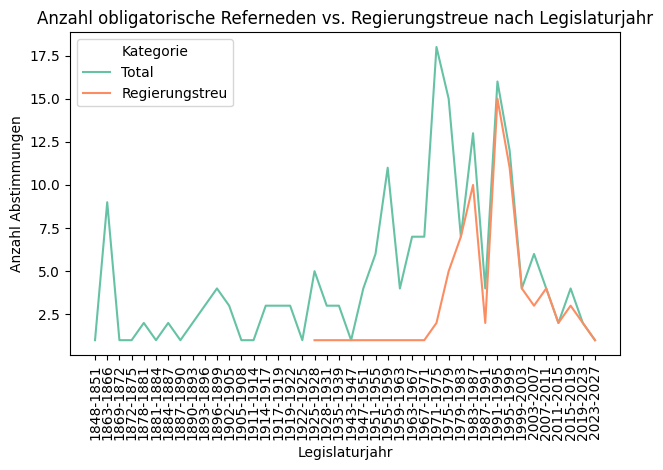

In [39]:
# df fakultatives Referendum über Zeit
or_df = data[(data["rechtsform_name"] == "Obligatorisches Referendum") & ((data["br-pos"] != "Missing") | (data["br-pos"] != 3))
].copy()

total = or_df.groupby("legisjahr").size().reset_index(name="anzahl")
total["Kategorie"] = "Total"

regtreu = or_df[or_df["regierungstreue"] == 1].groupby("legisjahr").size().reset_index(name="anzahl")
regtreu["Kategorie"] = "Regierungstreu"

combined = pd.concat([total, regtreu])

sns.lineplot(data=combined, x="legisjahr", y="anzahl", hue="Kategorie", palette="Set2")
plt.xlabel('Legislaturjahr')
plt.xticks(rotation=90)
plt.ylabel('Anzahl Abstimmungen')
plt.title('Anzahl obligatorische Referneden vs. Regierungstreue nach Legislaturjahr')
plt.tight_layout()
plt.show()

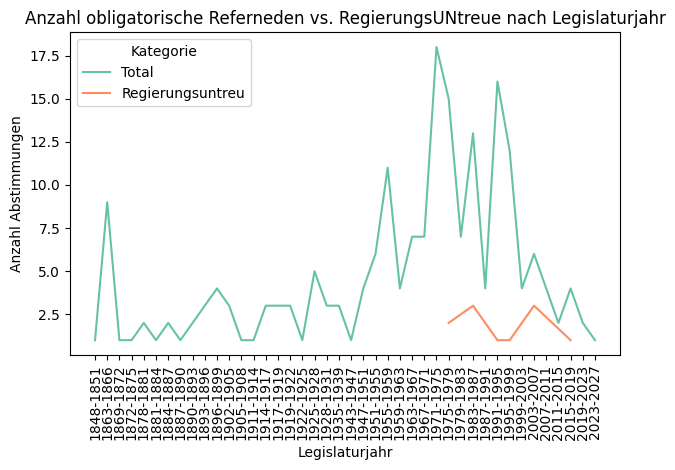

In [41]:
# df fakultatives Referendum über Zeit
or_df = data[(data["rechtsform_name"] == "Obligatorisches Referendum") & ((data["br-pos"] != "Missing") | (data["br-pos"] != 3))
].copy()

total = or_df.groupby("legisjahr").size().reset_index(name="anzahl")
total["Kategorie"] = "Total"

reguntreu = or_df[or_df["regierungstreue"] == 0].groupby("legisjahr").size().reset_index(name="anzahl")
reguntreu["Kategorie"] = "Regierungsuntreu"

combined_2 = pd.concat([total, reguntreu])

sns.lineplot(data=combined_2, x="legisjahr", y="anzahl", hue="Kategorie", palette="Set2")
plt.xlabel('Legislaturjahr')
plt.xticks(rotation=90)
plt.ylabel('Anzahl Abstimmungen')
plt.title('Anzahl obligatorische Referneden vs. RegierungsUNtreue nach Legislaturjahr')
plt.tight_layout()
plt.show()

In [ ]:
or_disagreement = or_df[
    (or_df["regierungstreue"] != 1)]
print(or_disagreement[["titel_kurz_d", "Hauptgruppe"]])
or_disagreement["Hauptgruppe"].value_counts()

### Visualisierungen Charlotte
--> Herausfinden weshalb die Positionen so fulkturieren? Welche instiutionellen Rahmenbedinungen erklären diese grossen unterschiede in den Ns?

In [ ]:
# Positionen Bundesrat
fig, ax = plt.subplots(figsize=(16, 7))

sns.histplot(
    data=data[data['br-pos_label'] != 'Missing'],
    x='legisjahr',
    hue='br-pos_label',
    multiple='stack',
    palette='Set2',
    ax=ax
)

sns.move_legend(ax, loc='upper left')

plt.xlabel('Legislaturjahr')
plt.xticks(rotation=90)
plt.ylabel('Anzahl Abstimmungen')
plt.title('Bundesratsposition nach Legislaturjahr')
plt.tight_layout()
plt.show()

In [ ]:
# Positionen Parlament
fig, ax = plt.subplots(figsize=(16, 7))

sns.histplot(
    data=data[data['bv-pos_label'] != 'Missing'],
    x='legisjahr',
    hue='bv-pos_label',
    multiple='stack',
    palette='Set2',
    ax=ax
)

sns.move_legend(ax, loc='upper left')

plt.xlabel('Legislaturjahr')
plt.xticks(rotation=90)
plt.ylabel('Anzahl Abstimmungen')
plt.title('Parlamentspositionen nach Legislaturjahr')
plt.tight_layout()
plt.show()

In [ ]:
# Unterschiede Anzahl Abstimmungsempfehlungen Berechnungen
recommendations = pd.DataFrame({
    'Parlament': data[data['bv-pos_label'] != 'Missing'].groupby('legisjahr')['bv-pos_label'].count(),
    'Bundesrat': data[data['br-pos_label'] != 'Missing'].groupby('legisjahr')['br-pos_label'].count()
})
missing_recommendations_br_bv = pd.DataFrame({
    'Parlament': data[data['bv-pos_label'] == 'Missing'].groupby('legisjahr')['bv-pos_label'].count(),
    'Bundesrat': data[data['br-pos_label'] == 'Missing'].groupby('legisjahr')['br-pos_label'].count()
    })
display(missing_recommendations_br_bv)

In [ ]:
# Unterschiede Anzahl Abstimmungsempfehlungen Plot
fig, ax = plt.subplots(figsize=(16, 7))

sns.lineplot(
    data=recommendations,
    palette='Set2',
    ax=ax
)

sns.move_legend(ax, loc='upper left')
plt.xlabel('Legislaturjahr')
plt.xticks(rotation=90)
plt.ylabel('Anzahl Abstimmungen')
plt.title('Empfehlungen nach Legislaturjahr')
plt.tight_layout()
plt.show()

### Erkenntnisse: Differenz in Anzahl Empfehlungen zwischen BR und Parlament in den Ersten Jahre betrifft wohl, dass man dazumals das Gefühl hatte, nicht unbedingt bei diesen beiden Rechtsformen eine Wahlempfehlung abgeben zu müssen. Allerdings sollten wir noch genauer in die Daten gehen

In [ ]:
missings = pd.DataFrame({
    'Direkter Gegenentwurf': data[data['rechtsform_name'] == 'Direkter Gegenentwurf'].groupby('legisjahr').size(),
    'Obligatorisches Referendum': data[data['rechtsform_name'] == 'Obligatorisches Referendum'].groupby('legisjahr').size(),
    'Missing Bundesrat': data[data['br-pos_label'] == 'Missing'].groupby('legisjahr').size()
}).fillna(0).astype(int)
print(display(missings))

## Bestehende Visualisierungen

### Regierungstreue des Volks im Vergleich zum Bundesrat (pro 10 Jahres Rhytmus) Figure.1

In [ ]:
plot_data = plot_data[plot_data['rechtsform_name'] != 'Direkter Gegenentwurf']

counts = plot_data.groupby('dekade').size()
valid_dekaden = counts[counts >= 5].index

plot_data = plot_data[plot_data['dekade'].isin(valid_dekaden)]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=plot_data,
    x='dekade',
    y='regierungstreue',
    hue='rechtsform_name',
    estimator='mean',
    errorbar=None,
    marker='o',
    linewidth=2.5
)

plt.title('Folgt das Volk dem Bundesrat? Regierungskonformität seit 1870')
plt.legend(title='Abstimmungstyp', loc='upper left')
plt.xlabel('Dekade')
plt.ylabel('Anteil regierungskonformer Abstimmungen')
plt.ylim(0,1)

plt.grid(alpha=0.3)

plt.show()

In [ ]:
#Charlottes Version
plt.figure(figsize=(20,6))
sns.lineplot(
    data=plot_data,
    x='legisjahr',
    y='regierungstreue',
    hue='rechtsform_name',
    estimator='mean',
    errorbar=None,
    marker='o',
    linewidth=2.5
)

plt.title('Folgt das Volk dem Bundesrat? Regierungskonformität seit 1870')
plt.legend(title='Abstimmungstyp', loc='upper left')
plt.xlabel('Dekade')
plt.ylabel('Anteil regierungskonformer Abstimmungen')
plt.xticks(rotation = 90)
plt.ylim(0,1)

plt.grid(alpha=0.3)

plt.show()

### Wo vertraut das Volk dem Bundesrat am meisten Figure.2

In [ ]:
plt.figure(figsize=(10,7))

topic_order = (
    plot_data.groupby('Hauptgruppe')['regierungstreue']
    .mean()
    .sort_values()
    .index
)

sns.barplot(
    data=plot_data,
    x='regierungstreue',
    y='Hauptgruppe',
    order=topic_order,
    estimator='mean',
    errorbar=None
)

plt.title('Wo folgt das Volk dem Bundesrat am häufigsten?')
plt.xlabel('Anteil regierungskonformer Abstimmungen')
plt.ylabel('Politikbereich')

plt.xlim(0,1)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()



### Wo vertraut das Volk dem Bundesrat am meisten Figure.3



In [ ]:
plot_data['abweichung'] = 1 - plot_data['regierungstreue']
plt.figure(figsize=(10,7))

topic_order = (
    plot_data.groupby('Hauptgruppe')['abweichung']
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.barplot(
    data=plot_data,
    x='abweichung',
    y='Hauptgruppe',
    order=topic_order,
    estimator='mean',
    errorbar=None
)

plt.title('Wo widerspricht das Volk dem Bundesrat am häufigsten?')
plt.xlabel('Anteil nicht regierungskonformer Abstimmungen')
plt.ylabel('Politikbereich')
plt.xlim(0,1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



### Wo vertraut das Volk dem Bundesrat am meisten Figure.4

In [ ]:
topic_summary = (
    plot_data.groupby('Hauptgruppe')['regierungstreue']
    .mean()
    .reset_index()
)

topic_summary['abweichung'] = 1 - topic_summary['regierungstreue']
topic_summary = topic_summary.sort_values('regierungstreue')

topic_long = topic_summary.melt(
    id_vars='Hauptgruppe',
    value_vars=['regierungstreue', 'abweichung'],
    var_name='Typ',
    value_name='Anteil'
)

plt.figure(figsize=(11,7))

sns.barplot(
    data=topic_long,
    x='Anteil',
    y='Hauptgruppe',
    hue='Typ'
)

plt.title('Folgt das Volk dem Bundesrat oder widerspricht es ihm?')
plt.xlabel('Anteil der Abstimmungen')
plt.ylabel('Politikbereich')
plt.xlim(0,1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()




### Gibt es regionale Unterschiede darin, wie stark Kantone der Empfehlung des Bundesrats folgen? (Boxplot) 
ungeeignet habe ihn dennoch mal drin gelassen

In [ ]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=kanton_df,
    x='Kanton',
    y='Ja_Anteil'
)

plt.title('Verteilung der Ja-Anteile nach Kanton')
plt.xlabel('Kanton')
plt.ylabel('Ja-Stimmen-Anteil')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



### Wie häufig folgen Kantone dem Bundesrat?


In [ ]:
# FacetGrid nach Sprachregion
g = sns.FacetGrid(
    kanton_summary,
    col="Sprachregion",
    col_wrap=3,
    height=5,
    sharex=True,
    sharey=False
)

g.map_dataframe(
    sns.barplot,
    x="kanton_regierungstreue",
    y="Kanton",
    order=kanton_summary.sort_values('kanton_regierungstreue')['Kanton']
)

g.set_axis_labels("Anteil regierungskonformer Abstimmungen", "Kanton")
g.set_titles("{col_name}")

g.fig.suptitle(
    "Kantonale Regierungstreue nach Sprachregion",
    y=1.03,
    fontsize=14
)

plt.xlim(0,1)
plt.tight_layout()
plt.show()


# Plot
plt.figure(figsize=(14, 8))

sns.barplot(
    data=kanton_summary,
    x='kanton_regierungstreue',
    y='Kanton',
    hue='Sprachregion'
)

plt.title('Kantonale Regierungstreue: Wie häufig folgen Kantone dem Bundesrat?')
plt.xlabel('Anteil kantonal regierungskonformer Abstimmungen')
plt.ylabel('Kanton')
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Visualisierung Nr. 3 – Der Röstigraben des Vertrauens

In [ ]:
# FacetGrid nach Sprachregion
g = sns.FacetGrid(
    kanton_summary,
    col="Sprachregion",
    col_wrap=3,
    height=5,
    sharex=True,
    sharey=False
)

g.map_dataframe(
    sns.barplot,
    x="kanton_regierungstreue",
    y="Kanton",
    order=kanton_summary.sort_values('kanton_regierungstreue')['Kanton']
)

g.set_axis_labels("Anteil regierungskonformer Abstimmungen", "Kanton")
g.set_titles("{col_name}")

g.fig.suptitle(
    "Der Röstigraben des Vertrauens: Kantonale Regierungstreue nach Sprachregion",
    y=1.03,
    fontsize=14
)

for ax in g.axes.flat:
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()




### Gibt es Regionale Unterschiede darin,wie stark die Kantone der Empfehlung des Bundesrates folgen?? Figure.5

In [ ]:
plt.figure(figsize=(16, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=50
)

plt.title("Durchschnittlicher Ja-Stimmen-Anteil nach Hauptgruppe und Kanton")
plt.xlabel("Kanton")
plt.ylabel("Hauptgruppe")
plt.tight_layout()
plt.show()